In [ ]:
!pip install numpy -q

In [ ]:
# Импорт библиотек, которые понадобятся
import numpy as np                                            # np — общепринятый короткий псевдоним NumPy
from numpy.random import default_rng                          # современный генератор случайных чисел (быстрее и точнее)
import time                                                   # чтобы замерять время выполнения
import matplotlib.pyplot as plt                               # для визуализации
import seaborn as sns                                         # стильные графики поверх Matplotlib
sns.set_theme(style="darkgrid")                               # включаем тёмную сетку — удобнее смотреть на графики
print("Библиотеки загружены!")                               # просто сигнал, что всё импортировалось без ошибок

Библиотеки загружены!


In [ ]:
# NumPy vs Python — честный замер скорости
# Если делать это в цикле Python, ждать придётся долго
# NumPy выполняет операции над всеми элементами одновременно (векторизация)

N = 1_000_000                                                # 1 миллион элементов — типичный размер клиентской базы
data_list = list(range(N))                                   # обычный Python-список от 0 до 999999
data_np = np.arange(N)                                       # NumPy-массив того же размера; функция arange — как range, но возвращает ndarray

# --- замер Python ---
start = time.time()                                          # запоминаем текущее время
doubled_list = [x * 2 for x in data_list]                   # list comprehension — это всё ещё Python-цикл
python_time = time.time() - start                            # сколько секунд прошло
print(f"Python list × 2: {python_time:.4f} сек")

# --- замер NumPy ---
start = time.time()                                          # запоминаем время снова
doubled_np = data_np * 2                                     # векторизованное умножение — выполняется на скорости C
numpy_time = time.time() - start
print(f"NumPy array × 2: {numpy_time:.4f} сек")

speedup = python_time / numpy_time                           # во сколько раз NumPy быстрее?
print(f"NumPy быстрее в {speedup:.0f} раз!")
# например, пересчитать DTI для миллиона клиентов — с NumPy это займёт миллисекунды

Python list × 2: 0.0549 сек
NumPy array × 2: 0.0039 сек
NumPy быстрее в 14 раз!


In [ ]:
# Создание массивов — 5 самых ходовых способов
# Массив (ndarray) — это таблица чисел, где все элементы одного типа
# NumPy хранит их в непрерывном блоке памяти — поэтому так быстро


# Из обычного Python-списка
arr = np.array([1, 2, 3, 4, 5])                              # самый простой способ; типы данных определяются автоматически
print("Из списка:", arr, "— тип элементов:", arr.dtype)

# Занулить (инициализация) — когда нужно подготовить пустую таблицу
zeros = np.zeros((3, 4))                                     # 3 строки, 4 столбца, все элементы — 0.0 (float64)
print("Нули:\n", zeros)

# Заполнить единицами — например, для начальных весов модели
ones = np.ones((2, 5))                                       # 2 строки, 5 столбцов, все элементы — 1.0
print("Единицы:\n", ones)

# Диапазон с шагом (как range) — самый быстрый способ получить последовательность чисел
nums = np.arange(0, 100, 5)                                  # от 0 до 100 (не включая 100) с шагом 5
print("Диапазон с шагом 5:", nums[:10])                     # первые 10 элементов

# Равномерный диапазон по числу точек — полезно для сетки значений
points = np.linspace(0, 1, 11)                               # 11 точек от 0 до 1 включительно
print("Равномерно от 0 до 1:", points)
# применение: linspace используют для генерации тестовых процентных ставок.

Из списка: [1 2 3 4 5] — тип элементов: int64
Нули:
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Единицы:
 [[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]
Диапазон с шагом 5: [ 0  5 10 15 20 25 30 35 40 45]
Равномерно от 0 до 1: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [ ]:
# Атрибуты массива — форма, тип, размер
# Эти свойства нужны, чтобы понимать, с какими данными работаешь

arr = np.random.randn(3, 4, 5)                               # трёхмерный массив 3×4×5 со случайными числами
print("Число измерений (ndim):", arr.ndim)                  # 3 — трёхмерный
print("Размеры (shape):", arr.shape)                         # (3, 4, 5) — блоков, строк, столбцов
print("Тип данных (dtype):", arr.dtype)                      # float64 — 64-битное дробное число
print("Всего элементов (size):", arr.size)                   # 3 × 4 × 5 = 60
print("Байт на элемент (itemsize):", arr.itemsize)           # 8 байт для float64
print("Общий размер в байтах (nbytes):", arr.nbytes)        # size × itemsize
# применение: зная shape и dtype, ты рассчитываешь, влезет ли датасет в память сервера

Число измерений (ndim): 3
Размеры (shape): (3, 4, 5)
Тип данных (dtype): float64
Всего элементов (size): 60
Байт на элемент (itemsize): 8
Общий размер в байтах (nbytes): 480


In [ ]:
# Индексация и срезы — выбираем нужное
# NumPy работает почти как Python-списки, но даёт гораздо больше возможностей

arr = np.arange(12).reshape(3, 4)                             # 3 строки, 4 столбца: числа от 0 до 11
print("Исходный массив:\n", arr)

# Один элемент
print("arr[1, 2] =", arr[1, 2])                              # вторая строка, третий столбец => 6

# Целый столбец
print("Второй столбец:", arr[:, 1])                          # все строки (":"), второй столбец => [1, 5, 9]

# Целая строка
print("Третья строка:", arr[2, :])                           # третья строка, все столбцы => [8, 9, 10, 11]

# Подматрица
print("Подматрица 0:2, 1:3:\n", arr[0:2, 1:3])              # первые 2 строки, столбцы 1 и 2 => [[1,2],[5,6]]

# Срез с шагом
print("Каждый второй столбец:\n", arr[:, ::2])               # все строки, столбцы с шагом 2 => [[0,2],[4,6],[8,10]]

# Отрицательные индексы
print("Последняя строка:", arr[-1, :])                       # -1 — последняя строка
# применение: срезы позволяют быстро достать, например, колонку «доход» или строки клиентов за последний месяц

Исходный массив:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
arr[1, 2] = 6
Второй столбец: [1 5 9]
Третья строка: [ 8  9 10 11]
Подматрица 0:2, 1:3:
 [[1 2]
 [5 6]]
Каждый второй столбец:
 [[ 0  2]
 [ 4  6]
 [ 8 10]]
Последняя строка: [ 8  9 10 11]


In [ ]:
# Булева индексация (соло) — фильтруем без циклов
# В банке постоянно нужно отбирать клиентов по условию:
# доход > 70k, возраст < 30, DTI > 0.5 и т.д.
# NumPy делает это через булевы маски — элегантно и быстро

rng = default_rng(42)                                        # создаём генератор с фиксированным seed для воспроизводимости
income = rng.normal(50000, 20000, 1000).astype(int)          # 1000 значений дохода (нормальное распределение), приводим к int

# Шаг 1: создаём булеву маску — массив True/False
mask = income > 70000                                        # условие: True там, где доход > 70000
print("Первые 10 масок:", mask[:10])                        # [False, True, ...]

# Шаг 2: применяем маску — оставляем только те элементы, где True
high_income = income[mask]                                   # это и есть булева индексация
print(f"Клиентов с доходом > 70k: {len(high_income)} из {len(income)}")
print(f"Их средний доход: {high_income.mean():.0f} руб.")

# Комбинированные условия: & (и), | (или), ~ (не)
age = rng.integers(21, 65, 1000)                             # возраст 1000 клиентов
complex_mask = (income > 50000) & (age < 30)                 # доход > 50k И возраст до 30 лет
young_rich = income[complex_mask]                            # выбираем только таких клиентов
print(f"Молодых и с доходом > 50k: {len(young_rich)} человек")
# применение: так отбирают рискованных заёмщиков для дополнительной проверки

Первые 10 масок: [False False False False False False False False False False]
Клиентов с доходом > 70k: 141 из 1000
Их средний доход: 80943 руб.
Молодых и с доходом > 50k: 98 человек


In [ ]:
# Фанатская индексация (фингерстайл) — выбор по списку индексов
# Обычные срезы берут подряд идущие строки/столбцы.
# А если нужны строки 0, 5 и 12? Тогда используют список индексов

arr = np.array([10, 20, 30, 40, 50])
indices = [0, 2, 4]                                          # список нужных индексов
selected = arr[indices]                                      # берём элементы с индексами 0, 2, 4
print("Элементы с индексами 0,2,4:", selected)              # [10, 30, 50]

# Для двумерного массива
matrix = np.arange(12).reshape(3, 4)                         # 3×4
print("Исходная матрица:\n", matrix)
rows = [0, 2]                                                # хотим строки 0 и 2
cols = [1, 3]                                                # и столбцы 1 и 3
result = matrix[np.ix_(rows, cols)]                          # np.ix_ создаёт «перекрестье» индексов
print("Пересечение строк [0,2] и столбцов [1,3]:\n", result)
# применение: выбор конкретных клиентов по их ID и конкретных колонок (например, доход и возраст)

Элементы с индексами 0,2,4: [10 30 50]
Исходная матрица:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
Пересечение строк [0,2] и столбцов [1,3]:
 [[ 1  3]
 [ 9 11]]


In [ ]:
# Универсальные функции (ufuncs) — гитарные примочки NumPy
# ufuncs применяют операцию к каждому элементу массива на скорости C
# Это как педаль distortion для гитары: на входе чистый сигнал, на выходе — перегруженный

a = np.array([1, 4, 9, 16, 25, 36, 49, 64, 81, 100])       # исходный массив

# Математические ufuncs — применяются поэлементно
print("Корень:", np.sqrt(a))                                 # квадратный корень
print("Экспонента (первые 5):", np.exp(a[:5]))               # e^x
print("Логарифм (первые 5):", np.log(a[:5]))                 # натуральный логарифм
print("Синус (первые 5):", np.sin(a[:5]))                    # синус угла в радианах

# Сравнения — возвращают булевы массивы
print("Больше 50:", np.greater(a, 50))                       # то же, что a > 50
print("Меньше или равно 25:", np.less_equal(a, 25))          # то же, что a <= 25

# Логические комбинации
print(">10 И <80:", np.logical_and(a > 10, a < 80))          # оба условия True
print(">90 ИЛИ <5:", np.logical_or(a > 90, a < 5))           # хотя бы одно True

# Накопительные операции (редукция)
print("Сумма всех:", np.add.reduce(a))                       # то же, что a.sum()
print("Произведение всех:", np.multiply.reduce(a))           # то же, что a.prod()
# применение: ufuncs позволяют быстро посчитать логарифм дохода для нормализации.

Корень: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
Экспонента (первые 5): [2.71828183e+00 5.45981500e+01 8.10308393e+03 8.88611052e+06
 7.20048993e+10]
Логарифм (первые 5): [0.         1.38629436 2.19722458 2.77258872 3.21887582]
Синус (первые 5): [ 0.84147098 -0.7568025   0.41211849 -0.28790332 -0.13235175]
Больше 50: [False False False False False False False  True  True  True]
Меньше или равно 25: [ True  True  True  True  True False False False False False]
>10 И <80: [False False False  True  True  True  True  True False False]
>90 ИЛИ <5: [ True  True False False False False False False False  True]
Сумма всех: 385
Произведение всех: 13168189440000


In [ ]:
# Агрегации — собираем массив в одно число
# В банковской отчётности постоянно нужны среднее, сумма, медиана
# NumPy считает их быстрее любых Python-циклов


scores = np.array([650, 720, 580, 690, 710, 640, 780])      # кредитные скоринги 7 клиентов

# Самые ходовые агрегации
print("Сумма баллов:", scores.sum())                         # сумма всех элементов
print("Средний скоринг:", scores.mean())                     # среднее арифметическое
print("Стандартное отклонение:", scores.std())               # разброс значений
print("Минимум:", scores.min())
print("Максимум:", scores.max())
print("Медиана:", np.median(scores))                         # 50-й перцентиль
print("Индекс максимального:", scores.argmax())              # позиция (индекс) максимального элемента
print("Индекс минимального:", scores.argmin())
# Банковское применение: средний скоринг по портфелю, разброс сумм кредита, минимальный/максимальный возраст

# Агрегации по осям: axis=0 — по столбцам, axis=1 — по строкам
matrix = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9]])
print("\nИсходная матрица:\n", matrix)
print("Сумма по столбцам (axis=0):", matrix.sum(axis=0))    # [12, 15, 18]
print("Сумма по строкам (axis=1):", matrix.sum(axis=1))      # [6, 15, 24]
print("Общая сумма:", matrix.sum())                           # 45
# применение: sum(axis=0) по колонке «доход» даст общий доход по всем клиентам

Сумма баллов: 4770
Средний скоринг: 681.4285714285714
Стандартное отклонение: 59.86379097073418
Минимум: 580
Максимум: 780
Медиана: 690.0
Индекс максимального: 6
Индекс минимального: 2

Исходная матрица:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]
Сумма по столбцам (axis=0): [12 15 18]
Сумма по строкам (axis=1): [ 6 15 24]
Общая сумма: 45


In [ ]:
# Линейная алгебра — симфонический металл
# Матричное умножение — основа регрессии, нейросетей и скоринга
# NumPy даёт 3 способа: @, np.matmul, np.dot — все работают одинаково

# Пример: 3 клиента, у каждого 2 признака (возраст, доход)
X = np.array([[1, 50000],                                    # клиент 1: возраст 1 (условный), доход 50 000
              [1, 75000],                                    # клиент 2
              [1, 40000]])                                   # клиент 3
weights = np.array([0.1, 0.00001])                           # веса модели (w0 и w1)
pred = X @ weights                                           # матричное умножение — получаем предсказание для всех трёх
print("Предсказания модели:", pred)

# Расширенный набор операций линейной алгебры
A = np.array([[1, 2],
              [3, 4]])
print("Транспонирование A.T:\n", A.T)                       # строки становятся столбцами и наоборот
print("След (сумма диагонали):", np.trace(A))                # 1 + 4 = 5
print("Определитель:", np.linalg.det(A))                     # |A| = 1×4 - 2×3 = -2
print("Обратная матрица:\n", np.linalg.inv(A))               # A⁻¹
eigenvalues, eigenvectors = np.linalg.eig(A)                  # собственные значения и векторы
print("Собственные значения:", eigenvalues)
print("Собственные векторы:\n", eigenvectors)
# применение: матричное умножение используется в линейной регрессии и нейросетях для предсказания дефолта

Предсказания модели: [0.6  0.85 0.5 ]
Транспонирование A.T:
 [[1 3]
 [2 4]]
След (сумма диагонали): 5
Определитель: -2.0000000000000004
Обратная матрица:
 [[-2.   1. ]
 [ 1.5 -0.5]]
Собственные значения: [-0.37228132  5.37228132]
Собственные векторы:
 [[-0.82456484 -0.41597356]
 [ 0.56576746 -0.90937671]]


In [ ]:
# Генератор случайных чисел (Generator API) — синтетические данные
# В реальных проектах данные часто заменяют синтетикой для тестов
# Современный NumPy использует Generator + PCG64 (быстрее и качественнее старого random.seed)

rng = default_rng(42)                                        # создаём генератор с seed 42 — для воспроизводимости

# Нормальное распределение (доходы)
income = rng.normal(50000, 20000, 1000)                      # среднее 50 000, разброс 20 000, 1000 значений
print("Нормальное (первые 5):", income[:5])

# Целые числа (возраст) — замена старого randint
age = rng.integers(21, 66, 1000)                             # от 21 до 65 включительно (66 не включительно)
print("Целые (первые 5):", age[:5])

# Биномиальное (дефолт — да/нет с вероятностью 10%)
default = rng.binomial(1, 0.1, 1000)                         # 1 с вероятностью 0.1, 0 — с 0.9
print(f"Доля дефолтов: {default.mean():.1%}")

# Равномерное от 0 до 1
uniform = rng.uniform(0, 1, 1000)                            # все значения равновероятны в диапазоне [0, 1)
print("Равномерное (первые 5):", uniform[:5])

# Выбор из списка
cities = rng.choice(['Москва', 'СПБ', 'Казань', 'Новосибирск', 'Екатеринбург'], 10)
print("Случайные города:", cities)
# применение: генерация синтетических клиентов для тестирования скоринговой модели

Нормальное (первые 5): [56094.34159509 29200.31787519 65009.02391613 68811.29432782
 10979.29622692]
Целые (первые 5): [29 50 39 36 52]
Доля дефолтов: 10.7%
Равномерное (первые 5): [0.58560376 0.78146584 0.37728184 0.01239721 0.50973466]
Случайные города: ['СПБ' 'Новосибирск' 'Новосибирск' 'СПБ' 'Новосибирск' 'Казань'
 'Екатеринбург' 'Москва' 'СПБ' 'СПБ']


In [ ]:
# Банковский кейс: расчёт DTI для 100 000 клиентов одной строкой
# DTI (debt-to-income) = сумма кредита / (доход × 12)

rng = default_rng(42)
N = 100_000                                                  # 100 тысяч клиентов
income = rng.normal(50000, 20000, N).clip(10000, None)       # доход не может быть меньше 10 000
loan = rng.normal(200000, 80000, N).clip(0, None)            # кредит не может быть отрицательным

dti = loan / (income * 12)                                   # векторизованный расчёт — мгновенно

print(f"Средний DTI: {dti.mean():.3f}")
print(f"Медианный DTI: {np.median(dti):.3f}")
print(f"Максимальный DTI: {dti.max():.3f}")
print(f"Доля рискованных (DTI > 0.5): {(dti > 0.5).mean():.1%}")
print(f"Топ-5 крупнейших кредитов: {np.sort(loan)[-5:]}")

Средний DTI: 0.422
Медианный DTI: 0.333
Максимальный DTI: 4.941
Доля рискованных (DTI > 0.5): 24.5%
Топ-5 крупнейших кредитов: [524976.10292631 566805.42367949 574389.33165249 592900.66483637
 599462.08953148]


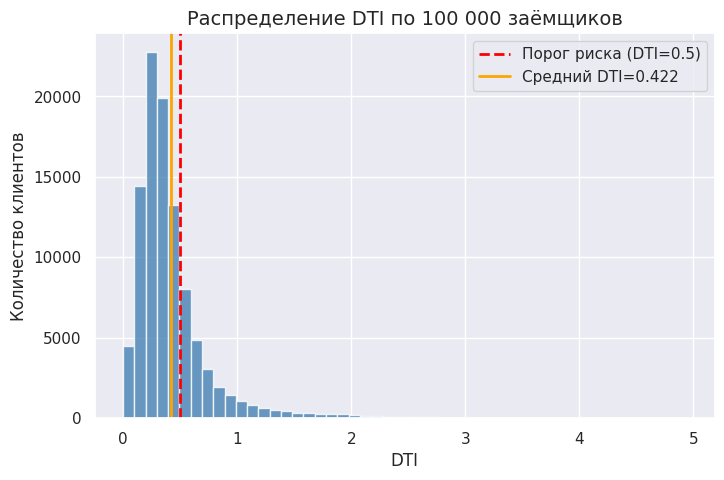

In [ ]:
# Визуализация DTI — ещё один взгляд на данные
plt.figure(figsize=(8, 5))                                   # размер графика в дюймах
plt.hist(dti, bins=50, color='steelblue', edgecolor='white', alpha=0.8)  # гистограмма
plt.axvline(0.5, color='red', linestyle='--', linewidth=2, label='Порог риска (DTI=0.5)')
plt.axvline(dti.mean(), color='orange', linestyle='-', linewidth=2, label=f'Средний DTI={dti.mean():.3f}')
plt.title('Распределение DTI по 100 000 заёмщиков', fontsize=14)
plt.xlabel('DTI')
plt.ylabel('Количество клиентов')
plt.legend()
plt.show()

In [ ]:
# Сохранение и загрузка массивов (бинарный формат .npy)
# NumPy умеет сохранять массивы быстро и компактно — это удобно для обмена

np.save('/tmp/scores.npy', scores)                            # сохраняем массив scores в файл scores.npy
loaded = np.load('/tmp/scores.npy')                           # загружаем обратно
print("Загруженный scores.npy:", loaded)

# Несколько массивов в одном файле (.npz)
np.savez('/tmp/bank_data.npz', income=income, loan=loan, dti=dti)  # сохраняем три массива с именами
archive = np.load('/tmp/bank_data.npz')                       # загружаем архив
print("\nМассивы в архиве:", list(archive.keys()))            # ['income', 'loan', 'dti']
print("Доходы из архива:", archive['income'][:5])            # доступ по имени
# применение: сохраняем предобработанные данные, чтобы не пересчитывать их каждый раз

Загруженный scores.npy: [650 720 580 690 710 640 780]

Массивы в архиве: ['income', 'loan', 'dti']
Доходы из архива: [56094.34159509 29200.31787519 65009.02391613 68811.29432782
 10979.29622692]


## 🎸 ТВОРЧЕСКОЕ ЗАДАНИЕ

1. Создай массив из 200 случайных доходов (normal, среднее 60000, разброс 15000) через Generator API.
2. Вычисли DTI для кредита в 400 000 руб. (одной строкой!).
3. Найди всех клиентов с DTI > 0.5 (булева индексация) и посчитай, сколько их.
4. Создай матрицу 3×3 и вектор из 3 элементов. Перемножь их через @, через matmul и через dot.
5. Сгенерируй 10 000 случайных городов и посчитай, сколько раз встретился каждый (np.unique с return_counts=True).
6. Сохрани массив DTI в .npy и загрузи обратно — проверь, что данные совпадают.

In [ ]:
# твой код